# 03 · V2 problem formulation and realistic validation

## 1. What are we trying to improve?
We predict a residential transaction amount in AED. This is supervised regression: inputs describe a property and the target is a historical recorded price. V2 improves the definition and measurement of the problem, not just R².

Three candidate targets ask different questions: total price, log total price, and unit price per square metre. **Every experiment is scored on reconstructed total AED**, on identical dates and rows within its population. We also compare a global model against exact-Flat and exact-Villa specialists.

Run `python -m src.preprocessing`, `python -m src.audit`, and `python -m src.model` from the project root to reproduce training. This notebook reads the frozen experiment reports rather than silently retraining or selecting a new winner.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import INPUT_COLUMNS, VERSION
from src.inference import load_artifacts
model, metadata = load_artifacts()
report = json.loads((ROOT / 'reports/evaluation.json').read_text())
assert report['project_version'] == VERSION
pd.set_option('display.max_columns', 10)
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')


## 2. Audit before modeling
V1 used an explicit feature whitelist and fitted scaling/category encoders inside each training split; no price-derived predictor was found. Its main weaknesses were limited project encoding, permissive schema handling and unresolved transaction scope.

V2 keeps the same residential sale allowlist and area-ratio heuristic for continuity. One Flat entry labeled Office is excluded as a semantic mismatch. Expensive properties and extreme unit prices are not automatically deleted. Development and lease-to-own procedures remain outside the modeling cohort pending domain review. Conflicting ID records are rejected; duplicates are not independent evidence.

Procedure type is excluded as a predictor because an ordinary app user cannot reliably know the eventual registration procedure. Parking bay IDs, identifiers, procedure area, diagnostic ratios and constants are excluded. Year/month/quarter, log surface, subtype, rooms, completion status, tenure, area and project are available before prediction.

In [2]:
display(pd.Series(json.loads((ROOT / 'data/processed/cleaning_audit.json').read_text()), name='rows'))
display(pd.Series(json.loads((ROOT / 'reports/v2_quality_audit.json').read_text())))
display(pd.read_csv(ROOT / 'reports/v2_procedure_audit.csv').head(15))

input_rows                       113866
outside_residential_sales         12865
excluded_procedure                 2745
invalid_date_price_or_surface         0
area_scope_mismatch                 249
commercial_room_mismatch              1
conflicting_transaction_id            0
duplicate_transaction_id             19
output_rows                       97987
Name: rows, dtype: int64

period                           Before 2026-07-09; residential subset before c...
rows                                                                         76886
development_registration_rows                                                 1690
ratio_outside_half_to_two                                                      206
unit_price_below_100_AED                                                         1
unit_price_above_100000_AED                                                     40
commercial_room_labels                                                           1
diagnostic_only                  100 and 100000 AED/m² are broad review thresho...
input_features                   [ACTUAL_AREA, INSTANCE_DATE, AREA_EN, PROP_SB_...
sale_procedures                  [Delayed Sell, Sale, Sale On Payment Plan, Sel...
dtype: object

,PROCEDURE_EN,rows,ratio_median,ratio_mean,ratio_max,median_price_per_sqm
0,Delayed Development,74,1.000,1.000,1.000,"9,579.246"
1,Delayed Sell,2101,1.000,0.993,1.005,"18,702.378"
2,Delayed Sell Development,2,1.000,1.000,1.000,"10,535.635"
3,Delayed Sell Lease to Own Registration,28,1.000,1.000,1.000,"16,096.020"
4,Development Registration,118,1.000,2.179,101.978,"9,685.960"
5,Development Registration Pre-Registration,1080,1.000,1.000,1.000,"12,904.768"
6,Lease to Own Registration,284,1.000,1.000,1.000,"15,425.268"
7,Lease to Own Registration Pre-Registration,1,1.000,1.000,1.000,"12,242.610"
8,Lease to Own on Development Registration,1,1.000,1.000,1.000,"8,968.059"
9,Sale,15765,1.000,0.991,2.000,"15,406.469"


## 3. Chronological validation and the honest holdout caveat
Training: earlier dates through June 11. External validation: June 12–July 8. Calibration: July 9–22. Comparison holdout: July 23 onward. Whole calendar dates never straddle partitions, and the same dates apply to all segments.

**Model selection uses validation MAE only, with RMSE as a tie-break.** R² is reported, not optimized in isolation. The two strongest nontrivial families receive three randomized parameter configurations on two expanding training-period folds. That is time-aware cross-validation: every fold trains earlier and validates later. The separate later validation period evaluates the tuned result.

Calibration labels are withheld from estimator fitting and selection. Final fitting combines training and validation dates, stopping July 8. This uses fewer fitting rows than V1 to reserve interval calibration.

The V1 holdout has already been examined in this project. It remains excluded from V2 selection, but cannot be called a genuinely untouched external dataset. A newly obtained later export is necessary for that stronger claim.

In [3]:
display(pd.DataFrame(report['date_ranges'], index=['start','end']).T)
display(pd.Series(report['rows'], name='rows'))
assert report['selection']['holdout_used_for_selection'] is False

,start,end
train,2026-01-01 16:21:33,2026-06-11 23:59:54
validation,2026-06-12 00:04:05,2026-07-08 23:38:24
calibration,2026-07-09 07:15:00,2026-07-22 23:06:42
test,2026-07-23 00:37:09,2026-09-11 11:44:44
development,2026-01-01 16:21:33,2026-07-08 23:38:24


train          65204
validation      9464
calibration     5222
test           18097
Name: rows, dtype: int64

## 4. Three leakage-safe target formulations
| Formulation | Training target | AED prediction |
|---|---|---|
| Direct | TRANS_VALUE | regression output |
| Log | log1p(TRANS_VALUE) | expm1(output) |
| Per m² | TRANS_VALUE / ACTUAL_AREA | output × ACTUAL_AREA |

Log transformation compresses the expensive tail and emphasizes relative errors. Its inverse is not automatically an unbiased estimate of mean price; this may help MAE while hurting RMSE on luxury sales. We do not use test-derived bias corrections.

Unit price is legitimate **as the target**, never as an input. The wrapper constructs it from y and known surface inside fit, then reconstructs total price inside predict. Surface is still a valid input. Both y and X are validated; unknown target-derived columns are rejected. All formulations apply an AED 1 floor to negative regression outputs, fixed before evaluation.

The dummy median is a baseline: complexity should beat a sensible constant prediction. Ridge regularizes linear coefficients; forests average trees; histogram boosting learns sequential residual patterns. CatBoost preserves project categories with native, training-local categorical processing. XGBoost/LightGBM are included by the factory only when installed; neither was available in this run.

,model,formulation,stage,MAE,RMSE,R2
15,catboost,per_sqm,tuned,"259,674.400","1,683,496.102",0.777
14,catboost,per_sqm,benchmark,"261,373.612","1,388,416.017",0.849
16,hist_gradient_boosting,per_sqm,tuned,"267,696.394","1,532,903.983",0.815
11,hist_gradient_boosting,per_sqm,benchmark,"278,419.544","1,553,279.475",0.810
10,hist_gradient_boosting,log,benchmark,"296,253.489","2,062,220.136",0.666
13,catboost,log,benchmark,"307,058.988","2,072,860.292",0.662
9,hist_gradient_boosting,direct,benchmark,"335,774.609","1,956,290.772",0.699
12,catboost,direct,benchmark,"337,965.988","2,097,110.603",0.654
7,random_forest,log,benchmark,"339,628.686","1,387,909.940",0.849
4,ridge,log,benchmark,"353,610.333","2,044,977.537",0.671


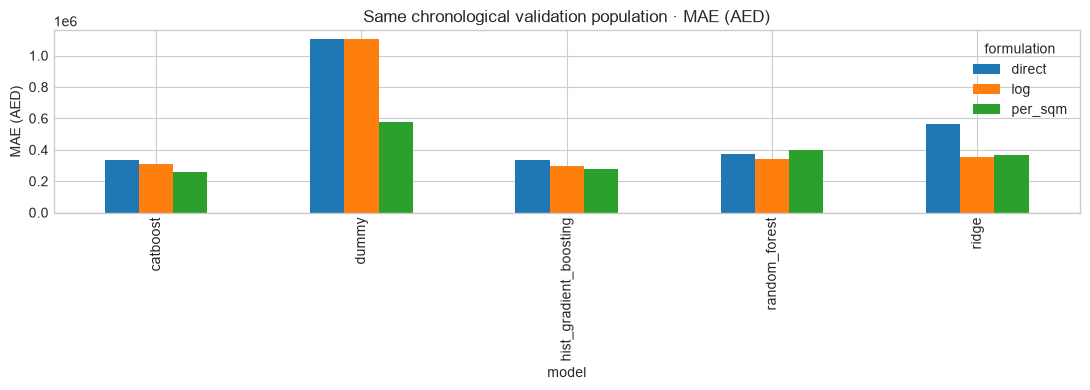

In [4]:
validation = pd.read_json(ROOT / 'reports/v2_validation.json')
display(validation[['model','formulation','stage','MAE','RMSE','R2']].sort_values('MAE'))
bench = validation.loc[validation.stage.eq('benchmark')]
bench.pivot(index='model',columns='formulation',values='MAE').plot.bar(figsize=(11,4), title='Same chronological validation population · MAE (AED)')
plt.ylabel('MAE (AED)'); plt.tight_layout(); plt.show()

## 5. Tuning, stability and practical complexity
Search scorers operate on the wrapper's AED predictions, so log and unit-price searches do not optimize incompatible scales. Encoders and estimators are cloned and fitted inside each fold. RandomizedSearchCV reports fold variability; two folds and three draws are a modest search, not exhaustive optimization.

The feature ablations remove log area or project while holding the selected model settings fixed. They are development-period diagnostics. The full feature contract was predeclared, so these ablations are not another test-driven selection loop.

In [5]:
for path in sorted((ROOT / 'reports').glob('v2_cv_*.csv')):
    print(path.stem)
    cv = pd.read_csv(path)
    display(cv[['params','mean_test_MAE','std_test_MAE','mean_test_RMSE','rank_test_MAE']])
print('CV scores above are negative errors: closer to zero is better.')
display(pd.read_csv(ROOT / 'reports/v2_feature_ablations.csv'))

v2_cv_catboost


,params,mean_test_MAE,std_test_MAE,mean_test_RMSE,rank_test_MAE
0,"{'pipeline__regressor__loss_function': 'MAE', ...","-343,130.905","18,551.010","-1,957,809.609",1
1,"{'pipeline__regressor__loss_function': 'MAE', ...","-346,835.945","23,955.285","-2,036,116.342",2
2,"{'pipeline__regressor__loss_function': 'RMSE',...","-360,228.221",174.602,"-1,972,366.273",3


v2_cv_hist_gradient_boosting


,params,mean_test_MAE,std_test_MAE,mean_test_RMSE,rank_test_MAE
0,"{'pipeline__regressor__max_leaf_nodes': 15, 'p...","-433,696.578","30,989.962","-2,514,077.541",3
1,"{'pipeline__regressor__max_leaf_nodes': 31, 'p...","-368,786.559","16,307.060","-2,030,308.589",1
2,"{'pipeline__regressor__max_leaf_nodes': 63, 'p...","-387,721.289","25,103.463","-2,249,885.982",2


CV scores above are negative errors: closer to zero is better.


,features,MAE,RMSE,R2
0,no_log_area,"260,119.388","1,643,393.222",0.788
1,no_project,"297,050.401","1,678,122.605",0.779
2,full,"259,674.400","1,683,496.102",0.777


## 6. Do specialists help?
Each segment candidate uses only its own earlier training rows, while the global model uses all residential training rows. They are compared on the **same segment validation records**. The winning candidate for each target formulation is tried as a specialist.

A specialist is routed into the application only if validation MAE improves by at least 2% and RMSE deteriorates by no more than 10%. The combined routed model must pass the same overall gate. This avoids adding operational complexity for tiny improvements. Broader Residential subtypes retain the global fallback; no label is silently reclassified as Flat or Villa.

In [6]:
display(pd.read_csv(ROOT / 'reports/v2_segment_validation.csv'))
print('Routing selected before holdout:', report['selection']['use_routing'])
display(pd.read_csv(ROOT / 'reports/v2_segment_holdout.csv'))

,segment,candidate,scope,MAE,RMSE,R2
0,Flat,hist_gradient_boosting__direct,specialist,"295,158.926","1,981,431.150",0.642
1,Flat,hist_gradient_boosting__log,specialist,"261,643.567","2,131,121.141",0.586
2,Flat,catboost__per_sqm__tuned,specialist,"225,637.924","1,637,691.899",0.755
3,Flat,catboost__per_sqm__tuned,global,"231,420.366","1,664,560.241",0.747
4,Villa,hist_gradient_boosting__direct,specialist,"723,711.173","1,690,625.239",0.798
5,Villa,hist_gradient_boosting__log,specialist,"621,082.010","1,358,963.988",0.869
6,Villa,catboost__per_sqm__tuned,specialist,"490,740.270","1,247,366.544",0.890
7,Villa,catboost__per_sqm__tuned,global,"504,556.773","1,144,199.149",0.907


Routing selected before holdout: True


,segment,scope,rows,MAE,RMSE,R2
0,Flat,global,16998,"262,151.356","1,072,745.846",0.795
1,Flat,specialist,16998,"248,241.301","1,035,303.151",0.809
2,Villa,global,1075,"714,237.390","5,558,693.432",0.532
3,Villa,specialist,1075,"751,734.690","6,101,899.014",0.436


## 7. Final comparison in AED
MAE is average absolute error. RMSE weighs large misses more heavily. R² compares squared error with predicting the evaluation population mean; it is not percentage accuracy and is not comparable across different segment populations.

The table includes the preselected winner of each formulation and the selected specialist candidates. **Do not select a different model from this final table.** Report the artifact selected earlier even if another candidate performs better here. Segment-only rows have different populations and must be compared to their corresponding global segment rows above, not the global headline.

Paired day-resampling compares V1 and V2 absolute errors on identical held-out records. Its interval is a diagnostic: adjacent dates and repeated properties may be dependent.

In [7]:
display(pd.read_csv(ROOT / 'reports/v2_comparison.csv'))
display(pd.DataFrame({'V1 same rows':report.get('v1_same_rows',{}), 'Selected V2':report['test_metrics']}))
print('Selected deployed model:', report['selected_model'], '| Target:', report['target'])
display(pd.Series(report.get('improvement_pct',{}), name='Error reduction (%)'))
display(pd.Series(report.get('paired_comparison',{})))

,model,formulation,target,split_strategy,rows,MAE,RMSE,R2
0,V1 hist_gradient_boosting,global,direct,same chronological future holdout,18097,"360,390.627","2,816,302.907",0.430
1,hist_gradient_boosting,global,direct,chronological future holdout,18097,"368,054.566","2,643,654.656",0.498
2,hist_gradient_boosting,global,log,chronological future holdout,18097,"321,747.526","2,635,767.715",0.501
3,catboost,global,per_sqm,chronological future holdout,18097,"305,127.032","2,171,196.478",0.661
4,catboost,Flat-only,per_sqm,"same future dates, segment subset",16998,"248,241.301","1,035,303.151",0.809
5,catboost,Villa-only,per_sqm,"same future dates, segment subset",1075,"751,734.690","6,101,899.014",0.436
6,segmented ensemble,routed,per_sqm,chronological future holdout,18097,"294,289.130","2,239,690.895",0.639


,V1 same rows,Selected V2
MAE,"360,390.627","294,289.130"
RMSE,"2,816,302.907","2,239,690.895"
R2,0.430,0.639


Selected deployed model: segmented ensemble | Target: per_sqm


MAE    18.342
RMSE   20.474
Name: Error reduction (%), dtype: float64

MAE_reduction_AED                                             66,101.497
day_bootstrap_95pct               [48583.54033943056, 85732.43053381857]
caveat                 Days may be dependent; this does not establish...
dtype: object

## 8. Empirical prediction intervals
We calibrate the 90% nominal quantile of absolute log residuals on the separate July 9–22 period, with the finite-sample rank correction. Multiplicative lower/upper bounds scale with predicted price. The estimator is not refitted after calibration, preserving calibration/inference parity.

This resembles split conformal prediction, but temporal drift breaks the exchangeability assumption. It is **not guaranteed confidence** for an individual property. We report actual holdout coverage and subgroup coverage, including where it fails.

In [8]:
display(pd.Series(report['interval']))
print(f"Holdout coverage: {report['interval_test_coverage']:.1%}")
print(f"Median interval width: AED {report['median_interval_width_AED']:,.0f}")
for name in ['PROP_SB_TYPE_EN','price_band','ROOMS_EN','IS_OFFPLAN_EN']:
    print(name)
    display(pd.read_csv(ROOT / f'reports/v2_errors_{name}.csv').head(15))

alpha                                                     0.100
log_radius                                                0.246
n                                                          5222
method        chronological split calibration, absolute log ...
caveat        Nominal coverage is not guaranteed under tempo...
dtype: object

Holdout coverage: 88.3%
Median interval width: AED 555,764
PROP_SB_TYPE_EN


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
0,Flat,16998,"248,241.301","1,035,303.151",0.809,"-44,464.465",0.886
1,Villa,1075,"751,734.690","6,101,899.014",0.436,"-349,932.845",0.846
2,Residential Flats,12,"21,999,902.621","51,307,261.485",0.379,"-18,905,996.362",0.417
3,Residential / Attached Villas,9,"164,467.711","242,351.396",0.618,"-58,324.924",0.778
4,Residential / Villas,3,"10,850,306.873","17,735,920.278",-1.855,"-10,850,306.873",0.667


price_band


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
0,<1M,7921,"118,687.300","371,832.215",-3.014,"71,415.993",0.887
1,1–2M,5721,"142,574.900","218,120.163",0.318,-240.469,0.919
2,2–5M,3808,"370,694.507","534,297.349",0.547,"-148,108.643",0.865
3,5–10M,466,"1,178,007.692","1,642,215.519",-0.772,"-664,632.846",0.687
4,10M+,181,"8,891,718.341","21,932,504.035",0.369,"-5,980,808.431",0.409


ROOMS_EN


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
0,Studio,6499,"61,483.072","121,376.738",0.594,"3,402.068",0.946
1,1 B/R,6424,"193,106.787","365,873.641",0.642,"-3,280.491",0.862
2,2 B/R,3281,"404,689.297","1,214,887.352",0.673,"-110,857.963",0.842
3,3 B/R,1150,"836,890.489","2,241,172.530",0.766,"-350,193.936",0.807
4,4 B/R,529,"1,203,664.067","3,462,808.256",0.772,"-268,262.286",0.849
5,5 B/R,161,"1,046,000.554","1,828,013.024",0.734,"-401,298.151",0.733
6,NaN,42,"8,198,862.154","27,911,770.547",0.499,"-5,767,949.645",0.571
7,PENTHOUSE,7,"940,453.784","1,685,324.927",-5.422,"885,771.653",0.714
8,6 B/R,4,"59,841,123.887","99,476,037.716",0.015,"-45,986,878.532",0.250


IS_OFFPLAN_EN


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
0,Off-Plan,13271,"219,641.542","1,051,108.843",0.824,"-91,964.149",0.925
1,Ready,4826,"499,562.264","3,971,412.873",0.546,"-35,531.778",0.768


## 9. Robustness and remaining limits
The serialized estimator contains feature engineering, native or one-hot encoding, scaling, target inversion and any segment routing. The app calls the same prediction method. Schema validation checks columns, types, dates, domain categories, finite values and surface bounds; optional categories may be missing, while unseen area/project names are supported. Metadata records configuration, periods, metrics, features, versions and a hash to detect mismatched artifacts.

The benchmark is a single partial-year market snapshot. Rare Residential labels may describe bulk transactions, ownership shares are unknown, and floor/view/condition are absent. There is no stable unit ID to prevent repeat-property overlap. Stronger model performance cannot resolve these definition problems. Collect a newer untouched extract and review transaction semantics before deploying this as a valuation product.